In [1]:
import nltk
from nltk.tokenize import word_tokenize # 문장을 단어 단위로 쪼개는 함수
import numpy as np

corpus = [
    "나는 자연어 처리를 공부한다",
    "자연어 처리는 재미있다",
    "나는 데이터 분석과 자연어 처리를 함께 공부한다"
]

tokenized_corpus = [ doc.split() for doc in corpus ]

doc_lengths = [len(token) for token in tokenized_corpus]

# 총 문서 수
N = len(corpus)

# 코퍼스 전체 토큰 수 = 모든 문서 길이의 합
T = sum(doc_lengths)

# 평균 문서 길이 = 전체 토큰 수 / 문서 수
mean_lengths = T / N
print(mean_lengths)



4.666666666666667


In [2]:
print(tokenized_corpus)

[['나는', '자연어', '처리를', '공부한다'], ['자연어', '처리는', '재미있다'], ['나는', '데이터', '분석과', '자연어', '처리를', '함께', '공부한다']]


In [3]:
vocabulary = set()

# update() : 여러 개를 한번에 집합에 추가하는 함수
# add() : 하나씩 집합에 추가
for tokens in tokenized_corpus:
    vocabulary.update(tokens)

print(f"vocabulary : {vocabulary}")

# 어휘 수 = 고유 토큰의 개수
V_size = len(vocabulary)
print(f"어휘 수 : {V_size}")

# TTR = 고유 토큰 수 / 전체 토큰 수
# 1에 가까울수록 어휘가 다양함
TTR = V_size / T
print(f"타입/토큰 비율 : {TTR}")

vocabulary : {'분석과', '처리는', '자연어', '재미있다', '처리를', '공부한다', '함께', '나는', '데이터'}
어휘 수 : 9
타입/토큰 비율 : 0.6428571428571429


In [4]:
from collections import Counter # 데이터 개수를 자동으로 세어주는 클래스
# => 딕셔너리를 상속받음 / 딕셔너리는 아니지만 딕셔너리 처럼 사용 가능
# 모든 문서의 토큰을 하나의 리스트로 합침
# 이중 리스트를 flat하게 펼치는 패턴
all_tokens = [ token for doc in tokenized_corpus for token in doc ]
token_freq = Counter(all_tokens)
print(f"토큰 빈도 : {token_freq}")

# 희소성 계산
# non_zero_cells : 각 문서에서 등장한 고유 단어 수의 합
# set(tokens) : 문서 내 중복 제거 => 고유 단어만
# len(set(tokens)) : 그 문서에서 실제로 값이 있는 칸의 수
non_zero_cells = sum( len( set(tokens) ) for tokens in tokenized_corpus )

# 문서-단어 행렬의 전체 칸 수 = 문서 수 * 어휘 수
total_cells = N * V_size

# 밀도 = 실제 값이 있는 칸 / 전체 칸
density = non_zero_cells / total_cells

# 희소성 = 1 - 밀도
# 0에 가까울수록 빽빽, 1에 가까울 수록 비어있음
sparsity = 1 - density

print(f"희소성 : {sparsity}")
print(f"문서-단어 행렬 전체 칸 수 : {total_cells}")
print(f"값이 있는 칸 수 : {non_zero_cells}")
print(f"밀도 : {density:.4f}")

토큰 빈도 : Counter({'자연어': 3, '나는': 2, '처리를': 2, '공부한다': 2, '처리는': 1, '재미있다': 1, '데이터': 1, '분석과': 1, '함께': 1})
희소성 : 0.4814814814814815
문서-단어 행렬 전체 칸 수 : 27
값이 있는 칸 수 : 14
밀도 : 0.5185


In [5]:
import matplotlib.pyplot as plt
from nltk.corpus import gutenberg
from nltk.tokenize import RegexpTokenizer # 정규 표현식을 이용해 문장을 규칙대로 토큰화하는 도구
from nltk.corpus import stopwords

nltk.download('gutenberg')
nltk.download('stopwords')
doc_alice = gutenberg.raw('carroll-alice.txt')

# 정규식으로 3글자 이상 단어만 추출 + 소문자화
# r'[\w]{3,}' : 문자/숫자/언더스코어/어퍼스트로피가 3개 이상인 것만 / {3} : 정확히 3개
# 'a', 'is', 'of' 같은 짧은 단어 자동 제거
tokenizer = RegexpTokenizer(r'[\w]{3,}')
reg_tokens_alice = tokenizer.tokenize(doc_alice.lower())

# 불용어 제거
english_stops = stopwords.words('english')
result_alice = [word for word in reg_tokens_alice if word not in english_stops]

# Counter로 단어 빈도 집계
alice_word_count = Counter(result_alice)
print(f"사용된 고유 단어 수 : {len(alice_word_count)}")

사용된 고유 단어 수 : 2405


[nltk_data] Downloading package gutenberg to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


상위 20개 고빈도 단어 : [('said', 462), ('alice', 398), ('little', 128), ('one', 104), ('know', 88), ('like', 85), ('would', 83), ('went', 83), ('could', 77), ('queen', 75), ('thought', 74), ('time', 71), ('see', 67), ('well', 63), ('king', 63), ('turtle', 59), ('began', 58), ('way', 56), ('hatter', 56), ('mock', 56)]
[462, 398, 128, 104, 88, 85, 83, 83, 77, 75, 74, 71, 67, 63, 63, 59, 58, 56, 56, 56, 55, 55, 53, 51, 51, 51, 51, 50, 49, 48, 48, 46, 46, 45, 45, 44, 44, 42, 41, 40, 40, 40, 40, 39, 39, 37, 34, 34, 33, 33, 32, 32, 32, 32, 32, 31, 31, 31, 31, 30, 30, 30, 30, 30, 29, 29, 29, 29, 29, 28, 28, 28, 27, 27, 27, 27, 27, 26, 26, 26, 25, 25, 25, 25, 25, 24, 24, 23, 23, 23, 22, 22, 22, 22, 22, 21, 21, 21, 21, 21, 21, 21, 20, 20, 20, 20, 19, 19, 19, 19, 19, 19, 19, 18, 18, 18, 18, 18, 18, 18, 18, 18, 17, 17, 17, 17, 17, 17, 17, 17, 17, 16, 16, 16, 16, 16, 16, 16, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14,

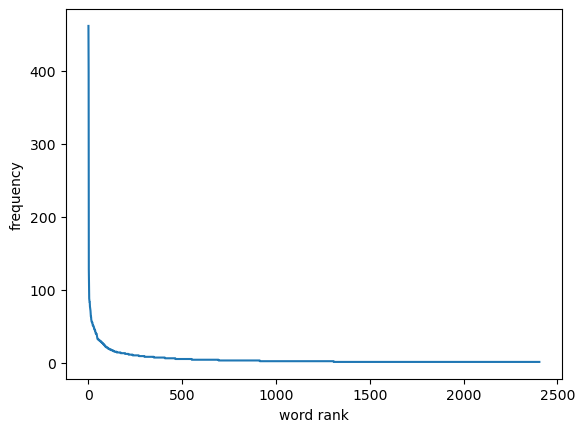

In [6]:
import matplotlib.pyplot as plt
# most_common(20) : 빈도 높은 순으로 상위 20개 반환 / Counter 전용 함수 (딕셔너리나, 리스트에서는 사용 불가)
# 결과 : [('alice', 403), ('said', 462),...] 형태의 튜플 리스트
top_20_words = alice_word_count.most_common(20) 
print(f"상위 20개 고빈도 단어 : {top_20_words}")

# 모든 단어 빈도를 내림차순으로 정렬
all_frequencies = sorted( list( alice_word_count.values() ), reverse=True )
print(all_frequencies)
# x축 : 단어 순위 (등수)
# y축 : 빈도 수

plt.plot(all_frequencies)
plt.xlabel('word rank')
plt.ylabel('frequency')
plt.show()


In [7]:
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize, RegexpTokenizer

# punkt_tab : nltk의 문장 분리 모델
# sent_tokenize가 문장을 구분할 때 내부적으로 사용됨
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('gutenberg')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package gutenberg to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!


True

In [8]:
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize, RegexpTokenizer

para = "Hello everyone. It's good to see you. Let's start our text mining class!"
para_kor = "안녕하세요, 여러분. 만나서 반갑습니다. 이제 텍스트마이닝 클래스를 시작해봅시다!"

# sent_tokenize : 마침표, 느낌표 기준으로 문장 단위 쪼갬
print(sent_tokenize(para))

# word_tokenize : 단어 + 구두점도 별도 토큰으로 분리
print(word_tokenize(para))
print(word_tokenize(para_kor))

# RegexpTokenizer : 정규식 패턴에 맞는 것만 토큰으로 추출
# r'[\w]+' : 문자/숫자가 1개 이상인 것만 => 구두점 자동 제거

tokenizer = RegexpTokenizer(r'[\w]+')
print(tokenizer.tokenize(para))

['Hello everyone.', "It's good to see you.", "Let's start our text mining class!"]
['Hello', 'everyone', '.', 'It', "'s", 'good', 'to', 'see', 'you', '.', 'Let', "'s", 'start', 'our', 'text', 'mining', 'class', '!']
['안녕하세요', ',', '여러분', '.', '만나서', '반갑습니다', '.', '이제', '텍스트마이닝', '클래스를', '시작해봅시다', '!']
['Hello', 'everyone', 'It', 's', 'good', 'to', 'see', 'you', 'Let', 's', 'start', 'our', 'text', 'mining', 'class']


In [9]:
# 불용어 제거
from nltk.corpus import stopwords

# stopwords.words('english') : nltk에 내장된 영어 불용어 목록
# set으로 변환하는 이유 : 리스트보다 set이 검색 속도가 훨씬 빠름
# 리스트 : 처음부터 하나씩 비교 0(n)
# set : 바로 찾아감 0(1)
english_stopword = set(stopwords.words('english'))

text_stop = "Sorry, I couldn't go to movie yesterday."

# RegexpTokenizer로 구두점 제거 + 토큰화
# lower() : 소문자화 먼저 하고 토큰화
tokenizer = RegexpTokenizer(r'[\w]+')
tokens = tokenizer.tokenize(text_stop.lower())

# nltk 기본 불용어로 제거
# 'i', 'to', 'couldn' 등이 불용어로 제거됨
result_nltk = [token for token in tokens if token not in english_stopword]
print(f"불용어 제거 후 : {result_nltk}")

# 사용자 정의 불용어
# 내가 직접 제거하고 싶은 단어 지정
my_stopword = ['i', 'go', 'to']
result_custom = [token for token in tokens if token not in my_stopword]
print(f"사용자 불용어 제거 후 : {result_custom}")

불용어 제거 후 : ['sorry', 'go', 'movie', 'yesterday']
사용자 불용어 제거 후 : ['sorry', 'couldn', 't', 'movie', 'yesterday']


In [10]:
from nltk.stem import PorterStemmer, WordNetLemmatizer

# PorterStemmer : 규칙 기반으로 단어 끝을 잘라내는 어간 추출기
# WordNetLemmatizer : 사전 기반으로 정확한 기본형을 찾는 표제어 추출기
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

nltk.download('wordnet') # lemmatizer가 참조하는 영어 사전 데이터

words = ['cooking', 'cookery', 'cookbooks', 'believes']

# f-string으로 표 형태로 출력
# {'Original':15} : 15칸 너비로 왼쪽 정렬
print(f"{'-'*15} {'-'*15} {'-'*15}")
print(f"{'Original':15} {'Stemming':15} {'Lemmatization':15}")
print(f"{'-'*15} {'-'*15} {'-'*15}")

for word in words:
    stemmed = stemmer.stem(word)            # 어간 추출
    lemmatized = lemmatizer.lemmatize(word) # 표제어 추출 (기본값: 명사)
    print(f"{word:15} {stemmed:15} {lemmatized:15}")

# 품사(POS) 지정한 표제어 추출
# pos='v' : 동사로 지정해서 추출
# believes -> belief(명사) vs believe(동사) 결과가 달라짐
lemmatizer.lemmatize("believes", pos='v')


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


--------------- --------------- ---------------
Original        Stemming        Lemmatization  
--------------- --------------- ---------------
cooking         cook            cooking        
cookery         cookeri         cookery        
cookbooks       cookbook        cookbook       
believes        believ          belief         


'believe'

In [11]:
from konlpy.tag import Okt

# Okt : Open Korean Text
# 한국어 형태소 분석기 중 하나
# 내부적으로 Java로 동작해서 JAVA_HOME 환경변수 필요
t = Okt()

sentence = '''절망의 반대가 희망은 아니다.
어두운 밤하늘에 별이 빛나듯
희망은 절망 속에 싹트는 거지
만약에 우리가 희망함이 적다면
그 누가 세상을 비출어줄까.
정희성, 희망 공부'''

# morphs() : 형태소 단위로 쪼개기
# 조사, 어미 등 모든 형태소 포함
print(t.morphs(sentence))

# nouns() : 명사만 추출
# 분석에서 가장 많이 쓰는 방법
# 명사가 핵심 의미를 담고 있기 때문
print(t.nouns(sentence))

# pos() : 품사 태깅
# (단어, 품사) 형태의 튜플 리스트로 반환
# Noun(명사), Josa(조사), Verb(동사), Adjective(형용사) 등
print(t.pos(sentence))

['절망', '의', '반대', '가', '희망', '은', '아니다', '.', '\n', '어', '두운', '밤하늘', '에', '별', '이', '빛나듯', '\n', '희망', '은', '절망', '속', '에', '싹트는', '거지', '\n', '만약', '에', '우리', '가', '희망', '함', '이', '적다면', '\n', '그', '누가', '세상', '을', '비출어줄까', '.', '\n', '정희성', ',', '희망', '공부']
['절망', '반대', '희망', '어', '두운', '밤하늘', '별', '희망', '절망', '속', '거지', '만약', '우리', '희망', '함', '그', '누가', '세상', '정희성', '희망', '공부']
[('절망', 'Noun'), ('의', 'Josa'), ('반대', 'Noun'), ('가', 'Josa'), ('희망', 'Noun'), ('은', 'Josa'), ('아니다', 'Adjective'), ('.', 'Punctuation'), ('\n', 'Foreign'), ('어', 'Noun'), ('두운', 'Noun'), ('밤하늘', 'Noun'), ('에', 'Josa'), ('별', 'Noun'), ('이', 'Josa'), ('빛나듯', 'Verb'), ('\n', 'Foreign'), ('희망', 'Noun'), ('은', 'Josa'), ('절망', 'Noun'), ('속', 'Noun'), ('에', 'Josa'), ('싹트는', 'Verb'), ('거지', 'Noun'), ('\n', 'Foreign'), ('만약', 'Noun'), ('에', 'Josa'), ('우리', 'Noun'), ('가', 'Josa'), ('희망', 'Noun'), ('함', 'Noun'), ('이', 'Josa'), ('적다면', 'Verb'), ('\n', 'Foreign'), ('그', 'Noun'), ('누가', 'Noun'), ('세상', 'Noun'), ('을', 'Jo

In [ ]:
corpus = [
    "나는 자연어 처리를 공부한다",
    "자연어 처리는 재미있다",
    "나는 자연어를 좋아하고 자연어 처리를 실습한다"
]

# 공백 기준으로 토큰화 
docs = [doc.split() for doc in corpus]

# 총 문서 수
N = len(docs) 

# 고유 어휘 집합 만들기
# 방법 1 ( 틀린 방법 )
# doc 안에 중복 X
vocab = []
for doc in docs:
    vocab.extend(doc)   # extend : 리스트에 여러 개 추가
                        # append와 차이 : append는 하나씩, extend는 여러개 => 중복 허용 (리스트 일 때, set이면 update => 중복 X)

vocab

['나는',
 '자연어',
 '처리를',
 '공부한다',
 '자연어',
 '처리는',
 '재미있다',
 '나는',
 '자연어를',
 '좋아하고',
 '자연어',
 '처리를',
 '실습한다']

In [ ]:
# 방법 2
# 그냥 중복 X
vocab = list( set( word for doc in docs for word in doc ) )
vocab

['처리는', '자연어', '재미있다', '처리를', '실습한다', '자연어를', '공부한다', '좋아하고', '나는']

In [14]:
import math

# TF : 문서 내부에서 특정 단어가 몇 번 나왔는지
# document.count(term) : 리스트에서 term이 몇 번 등장하는지 세는 함수
def compute_TF(term, document):
    return document.count(term)

# DF : 특정 단어가 몇 개의 문서에 등장하는지
# term in doc : doc 리스트 안에 term이 있으면 True
# 1 for doc in docs if term in doc : 있으면 1, 없으면 0
# sum() : 1들을 다 더하면 등장한 문서 수
def compute_DF(term, docs):
    return sum([1 for doc in docs if term in doc])

# IDF : 희귀한 단어일수록 높은 값
# N은 전역변수로 위에서 선언한 총 문서 수
# 스무딩 버전 : (N+1) / (df+1) -> 0으로 나누는 문제 방지
# +1 : 마지막에 더하는 건 값이 너무 작아지는 것 방지
def compute_IDF(term, docs):
    df = compute_DF(term, docs)
    return math.log((N + 1) / (df + 1)) + 1 # 함수 밖에서 선언한 변수를 함수 안에서 쓸 수 있음 => 전역 변수

# TF-IDF : TF X IDF
# 문서 안에서 자주 + 전체에서 희귀한 단어를 강조
def compute_TFIDF(term, document, docs):
    tf = compute_TF(term, document)
    idf = compute_IDF(term,docs)
    return tf * idf


In [15]:
word1 = '자연어'
word2 = '공부한다'

# docs[0] : 첫 번째 문서 -> ['나는', '자연어', '처리를', '공부한다']
print(docs[0])

# word1(자연어): 3개 문서 모두 등장 → DF 높음 → IDF 낮음 → TF-IDF 낮음
print(f"word1 tf-idf : {compute_TFIDF(word1, docs[0], docs)}")

# word2(공부한다): 1개 문서에만 등장 → DF 낮음 → IDF 높음 → TF-IDF 높음
print(f"word2 tf-idf : {compute_TFIDF(word2, docs[0], docs)}")

['나는', '자연어', '처리를', '공부한다']
word1 tf-idf : 1.0
word2 tf-idf : 1.6931471805599454


In [16]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import pandas as pd

# CountVectorizer : 단어 등장 횟수로 문서-단어 행렬 만들기
cv = CountVectorizer()

# fit_transform : 두 가지를 한번에 수행
# fit : 코퍼스에서 어휘 집합 학습
# transform : 학습한 어휘로 문서를 벡터로 변환
dtm = cv.fit_transform(corpus)

# get_feature_names_out() : 어휘 집합 확인
# 알파벳 순으로 자동 정렬 됨
print(f"Scikit-Learn 어휘 : {cv.get_feature_names_out()}")

# dtm.toarray() : 희소행렬(sparse matrix) -> 일반 numpy 배열로 변환
# 희소 행렬 : 0이 많은 행렬을 메모리 효율적으로 저장하는 방식
# toarray()없으면 숫자가 아닌 특수한 형태로 출력됨
df_dtm = pd.DataFrame(dtm.toarray(), columns=cv.get_feature_names_out())
df_dtm

Scikit-Learn 어휘 : ['공부한다' '나는' '실습한다' '자연어' '자연어를' '재미있다' '좋아하고' '처리는' '처리를']


,공부한다,나는,실습한다,자연어,자연어를,재미있다,좋아하고,처리는,처리를
0,1,1,0,1,0,0,0,0,1
1,0,0,0,1,0,1,0,1,0
2,0,1,1,1,1,0,1,0,1


In [17]:
# TfidfVectorizer : CountVectorizer + TF-IDF 계산을 한번에
# 내부적으로 L2 정규화까지 자동으로 적용
tfidf_vec = TfidfVectorizer()

# fit_transform : 어휘 학습 + TF-IDF 벡터로 변환
tfidf_matrix = tfidf_vec.fit_transform(corpus)

# toarray() : 희소행력 -> 일반 numpy 배열
# get_feature_names_out() : 어휘 집합
df_tfidf = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns = tfidf_vec.get_feature_names_out()
)
df_tfidf

,공부한다,나는,실습한다,자연어,자연어를,재미있다,좋아하고,처리는,처리를
0,0.631745,0.480458,0.00000,0.373119,0.00000,0.000000,0.00000,0.000000,0.480458
1,0.000000,0.000000,0.00000,0.385372,0.00000,0.652491,0.00000,0.652491,0.000000
2,0.000000,0.358291,0.47111,0.278245,0.47111,0.000000,0.47111,0.000000,0.358291


In [20]:
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity

# 2차원 배열로 만들어야 함
# sklearn은 항상 2차원 배열을 입력으로 받음
#[3, 4] (1차원) -> [[3,4], [1,2]] (2차원)
vectors = np.array([
    [3, 4], 
    [1, 2]
])

# normalize : 벡터 정규화
# norm='l2' : L2 정규화 적용
# norm='l1' : L1 정규화 적용
l2_normalized = normalize(vectors, norm='l2')
print(f"L2 정규화 :\n {l2_normalized}")

# cosine_similarity : 모든 벡터 쌍의 유사도를 한번에 계산
# 결과 : 2X2 행렬 (유사도 행렬)
# [문서1 - 문서1, 문서1 - 문서2]
# [문서2 - 문서1, 문서2 - 문서2]
sim_matrix = cosine_similarity(vectors)
sim_matrix

L2 정규화 :
 [[0.6        0.8       ]
 [0.4472136  0.89442719]]


array([[1.        , 0.98386991],
       [0.98386991, 1.        ]])

In [22]:
import nltk
from nltk.corpus import movie_reviews
from sklearn.feature_extraction.text import TfidfVectorizer

# movie_reviews : nltk 내장 영화 리뷰 데이터셋
# 긍정/부정 리뷰 각각 1000개 총 2000개 리뷰 포함
nltk.download('movie_reviews')

# movie_reviews.fileids(): 모든 파일 이름 목록
# movie_reviews.raw(filed) : 파일을 텍스트로 읽어옴
reviews = [movie_reviews.raw(filed) for filed in movie_reviews.fileids()[:100]]

# 첫 번째 리뷰 확인
reviews[0]

[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!


'plot : two teen couples go to a church party , drink and then drive . \nthey get into an accident . \none of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . \nwhat\'s the deal ? \nwatch the movie and " sorta " find out . . . \ncritique : a mind-fuck movie for the teen generation that touches on a very cool idea , but presents it in a very bad package . \nwhich is what makes this review an even harder one to write , since i generally applaud films which attempt to break the mold , mess with your head and such ( lost highway & memento ) , but there are good and bad ways of making all types of films , and these folks just didn\'t snag this one correctly . \nthey seem to have taken this pretty neat concept , but executed it terribly . \nso what are the problems with the movie ? \nwell , its main problem is that it\'s simply too jumbled . \nit starts off " normal " but then downshifts into this " fantasy " world in which you , as an audience membe

In [23]:
# max_features=1000: 전체 어휘 중 빈도 높은 상위 1000개만 사용
# 이유: 어휘가 너무 많으면 행렬이 너무 커져서 메모리/속도 문제
# TfidfVectorizer 내부적으로 L2 정규화 자동 적용
tf = TfidfVectorizer(max_features=1000)
reviews_tfidf = tf.fit_transform(reviews)

# shape: (문서 수, 어휘 수)
reviews_tfidf.shape  # → (100, 1000)

(100, 1000)

In [24]:
# reviews[0]의 뒷부분 절반을 검색 쿼리로 사용
# len(reviews[0]) // 2: 문서 길이의 절반 (// 정수 나눗셈)
# reviews[0][-start:]: 뒤에서 start만큼 슬라이싱
start = len(reviews[0]) // 2
source = reviews[0][-start:]
print(f"검색할 문서 일부")
print(source[:200] + "...")  # 앞 200글자만 출력

# transform: fit은 이미 했으니까 변환만!
# 새로운 문서를 기존 어휘로 벡터화
# fit_transform 쓰면 안되는 이유:
# → 새로운 어휘로 다시 학습하면 기존 벡터랑 차원이 달라짐
source_tfidf = tf.transform([source])

# cosine_similarity(A, B)
# A: 검색할 문서 벡터 (1 × 1000)
# B: 전체 문서 벡터 (100 × 1000)
# 결과: (1 × 100) → 검색 문서와 각 문서의 유사도
sim_result_tfidf = cosine_similarity(source_tfidf, reviews_tfidf)

# shape 확인
sim_result_tfidf.shape  # → (1, 100)

검색할 문서 일부
taining . 
i guess the bottom line with movies like this is that you should always make sure that the audience is " into it " even before they are given the secret password to enter your world of unde...


(1, 100)

In [25]:
# np.argsort: 값을 오름차순으로 정렬한 인덱스 반환
# -sim_result_tfidf: 음수로 바꿔서 argsort하면 내림차순 효과
# 예: [0.1, 0.9, 0.5] → argsort → [0, 2, 1]
#     [-0.1, -0.9, -0.5] → argsort → [1, 2, 0] (내림차순!)
top_index = np.argsort(-sim_result_tfidf).reshape(-1)[:5]
# reshape(-1): 2차원 → 1차원으로 변환
# [:5]: 상위 5개만

print(f'1위 인덱스 {top_index[0]} 의 유사도 점수 {sim_result_tfidf[0][top_index[0]]}')
print(f'2위 인덱스 {top_index[1]} 의 유사도 점수 {sim_result_tfidf[0][top_index[1]]}')

# 실제 문서 내용 출력
print(f"검색할 문장 : {source}\n")
print(f"가장 유사한 문장 : {reviews[0]}\n")       # 1위
print(f"두 번째로 유사한 문장 : {reviews[1]}")     # 2위

1위 인덱스 0 의 유사도 점수 0.8840616506405607
2위 인덱스 9 의 유사도 점수 0.6287543120940827
검색할 문장 : taining . 
i guess the bottom line with movies like this is that you should always make sure that the audience is " into it " even before they are given the secret password to enter your world of understanding . 
i mean , showing melissa sagemiller running away from visions for about 20 minutes throughout the movie is just plain lazy ! ! 
okay , we get it . . . there 
are people chasing her and we don't know who they are . 
do we really need to see it over and over again ? 
how about giving us different scenes offering further insight into all of the strangeness going down in the movie ? 
apparently , the studio took this film away from its director and chopped it up themselves , and it shows . 
there might've been a pretty decent teen mind-fuck movie in here somewhere , but i guess " the suits " decided that turning it into a music video with little edge , would make more sense . 
the actors are pretty 